# A-GHOST: Cross-BX Anomaly Detection — Performance Analysis

Loads the trained Conv1D autoencoder (ONNX) and evaluates it on the held-out test set (`crossBX_test.parquet`). Each event is a triplet of consecutive bunch crossings (BX−1, BX, BX+1) with 8 digitized gFEX MET features per BX. Anomaly score = per-event MSE reconstruction error.

**Sections**
1. Load model & data
2. Run inference
3. Anomaly score distribution + threshold
4. Feature distributions: anomalous vs. all events
5. Per-feature reconstruction error heatmap
6. Cross-BX MET correlation analysis

In [60]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import onnxruntime as rt
from pathlib import Path

BASE_FEATURES = [
    "mhxDigi", "mhyDigi",
    "msxDigi", "msyDigi",
    "metxDigi", "metyDigi",
    "metDigi", "sumEtDigi",
]
BX_LABELS  = ["BX-1", "BX", "BX+1"]
N_BX, N_FEAT = 3, len(BASE_FEATURES)
SCALE = 0.2   # digitization unit → GeV (200 MeV / unit)

TRAIN_OUT_DIR        = Path("train_crossBX_gFEXMET_out")
ONNX_PATH            = TRAIN_OUT_DIR / "cross_BX_gFEXMET_autoencoder.onnx"
SCALER_PATH          = TRAIN_OUT_DIR / "scaler.joblib"
TEST_PATH            = TRAIN_OUT_DIR / "crossBX_test.parquet"
THRESHOLD_PERCENTILE = 99
OUT_DIR              = Path("performance_gFEX_MET_AD")

OUT_DIR.mkdir(exist_ok=True)
print(f"Plots will be saved to: {OUT_DIR.resolve()}")

Plots will be saved to: /eos/home-i03/m/mlarson/AGHOST_gFEX/codeDir/performance_gFEX_MET_AD


## 1. Load Model & Data

In [61]:
# Suppress pthread_setaffinity_np errors on many-core nodes
opts = rt.SessionOptions()
opts.intra_op_num_threads = 4
opts.inter_op_num_threads = 1

sess        = rt.InferenceSession(ONNX_PATH, sess_options=opts)
input_name  = sess.get_inputs()[0].name
output_name = sess.get_outputs()[0].name
print(f"Model input : {sess.get_inputs()[0].shape}")
print(f"Model output: {sess.get_outputs()[0].shape}")

df_test = pd.read_parquet(TEST_PATH)
print(f"\nTest set: {len(df_test):,} events, {df_test.shape[1]} columns")
df_test.head()

Model input : ['unk__148', 3, 8]
Model output: ['unk__149', 3, 8]

Test set: 257,269 events, 24 columns


,mhxDigi_prev,mhyDigi_prev,msxDigi_prev,msyDigi_prev,metxDigi_prev,metyDigi_prev,metDigi_prev,sumEtDigi_prev,mhxDigi_curr,mhyDigi_curr,...,metDigi_curr,sumEtDigi_curr,mhxDigi_next,mhyDigi_next,msxDigi_next,msyDigi_next,metxDigi_next,metyDigi_next,metDigi_next,sumEtDigi_next
0,0.011257,0.000418,-0.016973,1.992841,-0.132938,0.874574,-0.124063,-0.465807,-0.494212,2.355849,...,0.339615,1.783598,0.011257,0.000418,-1.433088,-0.918963,-0.612811,-0.304297,-0.301351,-0.465807
1,1.554267,-4.250189,-1.716311,2.476268,0.986765,-3.312451,2.439803,2.039675,0.011257,0.000418,...,-0.655928,-0.465807,0.011257,0.000418,0.379540,0.902320,-0.132938,0.427416,-0.560465,-0.465807
2,-0.028648,-0.310933,-1.659667,-0.761568,-0.226247,-0.588852,-0.383177,1.021186,0.011257,0.000418,...,-0.533190,-0.465807,0.011257,0.000418,0.696749,-1.503572,0.413584,-0.724355,-0.219526,-0.465807
3,-0.148364,-1.326205,2.566022,-0.221929,0.600201,-1.496718,0.571454,0.375173,0.011257,0.000418,...,-0.505915,-0.465807,0.436915,0.514822,0.243593,0.362680,0.586871,0.820373,-0.028600,-0.323219
4,0.011257,0.000418,-0.504116,1.576869,-0.146268,0.644220,-0.342264,-0.465807,-4.617773,-1.055465,...,2.548903,3.995173,0.011257,0.000418,-0.492787,0.418893,-0.266236,0.278363,-0.601378,-0.465807


In [62]:
# Reshape flat (N, 24) → (N, 3, 8) in [prev | curr | next] order
ordered_cols = (
    [f"{f}_prev" for f in BASE_FEATURES]
    + [f"{f}_curr" for f in BASE_FEATURES]
    + [f"{f}_next" for f in BASE_FEATURES]
)
X = df_test[ordered_cols].to_numpy(dtype="float32").reshape(-1, N_BX, N_FEAT)
print(f"Scaled input tensor shape: {X.shape}  (N, BX, features)")

# Inverse-transform back to original digitized units for plotting
# Scaler was fit on (N*3, 8) — apply the same reshaping
scaler = joblib.load(SCALER_PATH)
X_orig = scaler.inverse_transform(X.reshape(-1, N_FEAT)).reshape(-1, N_BX, N_FEAT)
print(f"Unscaled tensor shape:     {X_orig.shape}")

Scaled input tensor shape: (257269, 3, 8)  (N, BX, features)
Unscaled tensor shape:     (257269, 3, 8)


## 2. Run Inference

In [63]:
X_recon = sess.run([output_name], {input_name: X})[0]   # (N, 3, 8)

# Per-event anomaly score: mean squared error over all BX positions and features
anomaly_score = np.mean((X - X_recon) ** 2, axis=(1, 2))  # (N,)

threshold = np.percentile(anomaly_score, THRESHOLD_PERCENTILE)
is_anomaly = anomaly_score > threshold

print(f"Threshold ({THRESHOLD_PERCENTILE}th percentile): {threshold:.6f}")
print(f"Anomalous events : {is_anomaly.sum():,} / {len(is_anomaly):,}  ({100*is_anomaly.mean():.1f}%)")

Threshold (99th percentile): 0.021496
Anomalous events : 2,573 / 257,269  (1.0%)


## 3. Anomaly Score Distribution

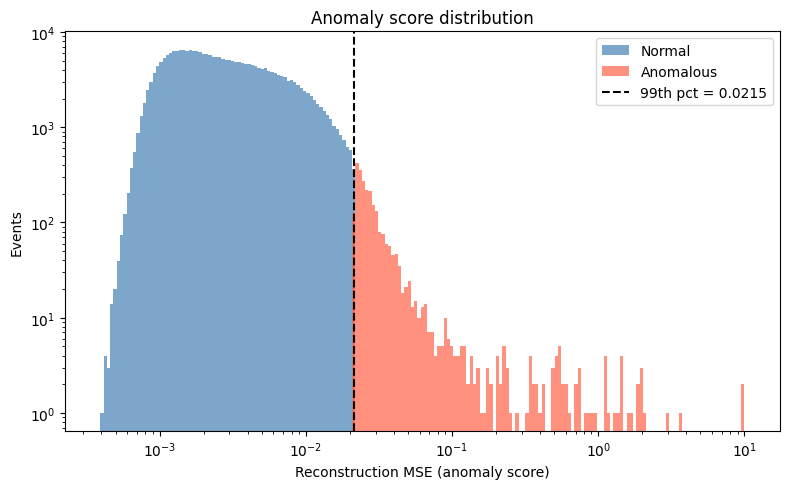

In [64]:
fig, ax = plt.subplots(figsize=(8, 5))

bins = np.logspace(np.log10(anomaly_score.min() + 1e-9), np.log10(anomaly_score.max()), 200)

ax.hist(anomaly_score[~is_anomaly], bins=bins, alpha=0.7, label="Normal",    color="steelblue")
ax.hist(anomaly_score[ is_anomaly], bins=bins, alpha=0.7, label="Anomalous", color="tomato")
ax.axvline(threshold, color="black", linestyle="--", linewidth=1.5,
           label=f"{THRESHOLD_PERCENTILE}th pct = {threshold:.4f}")
ax.set_xlabel("Reconstruction MSE (anomaly score)")
ax.set_ylabel("Events")
ax.set_xscale("log")
ax.set_yscale("log")
ax.legend()
ax.set_title("Anomaly score distribution")

plt.tight_layout()
plt.savefig(OUT_DIR / "anomaly_score_distribution.png", dpi=150)
plt.show()

## 4. Feature Distributions: Anomalous vs. All Events

For each of the 8 gFEX MET features, compare distributions between anomalous and normal events across all three BX positions (BX−1, BX, BX+1). Values are converted to GeV (×0.2).

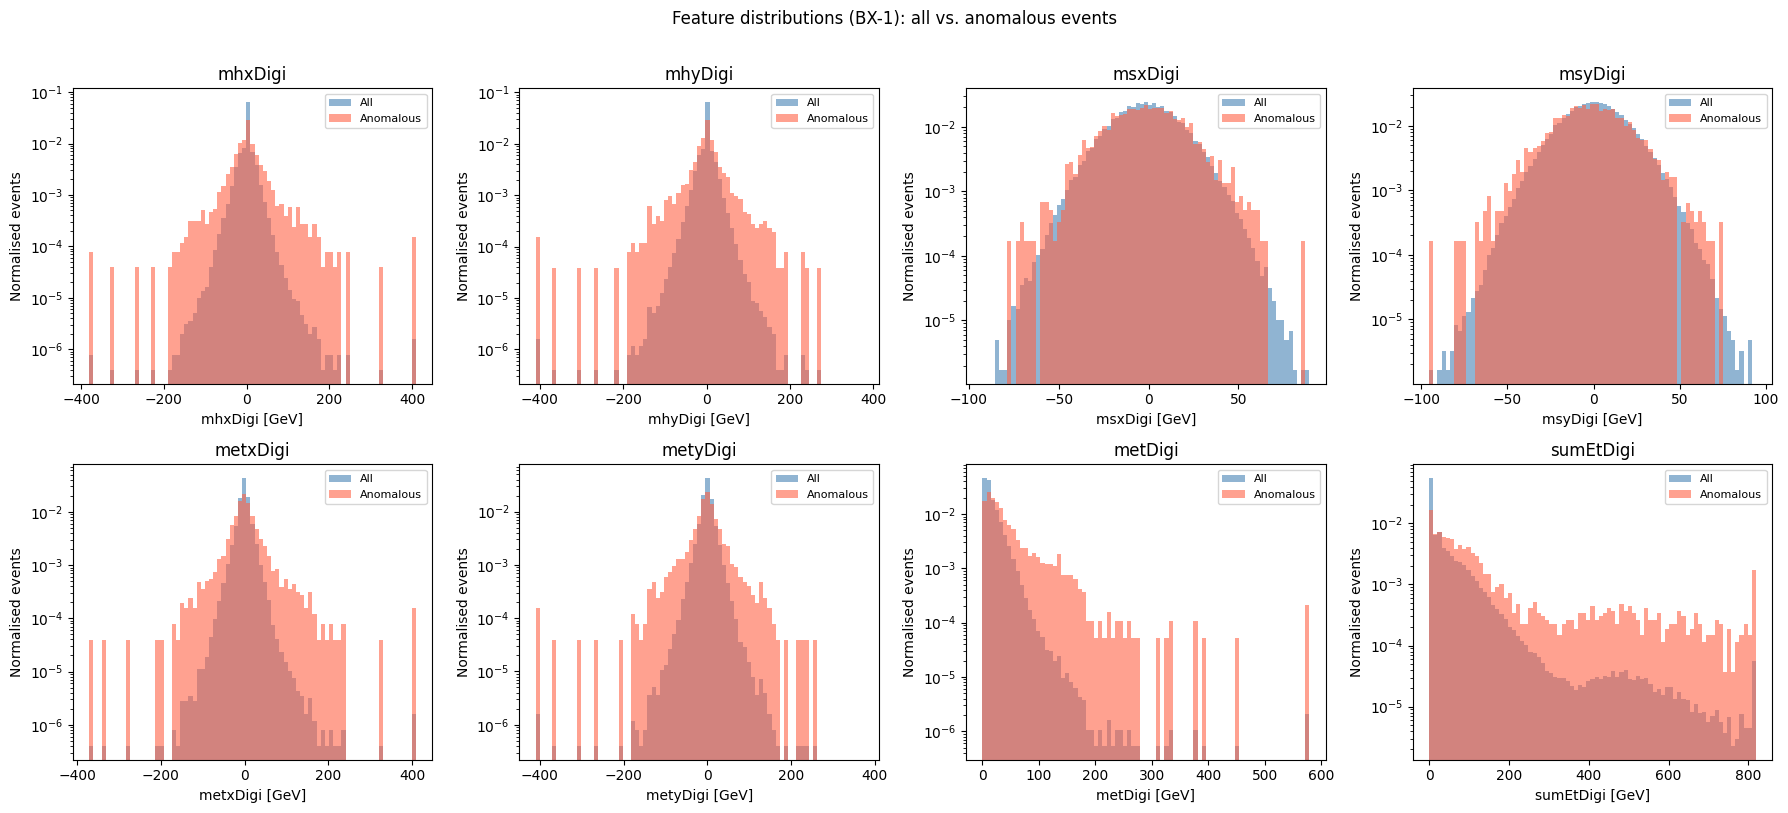

Saved: performance_gFEX_MET_AD/feature_distributions_BXm1.png


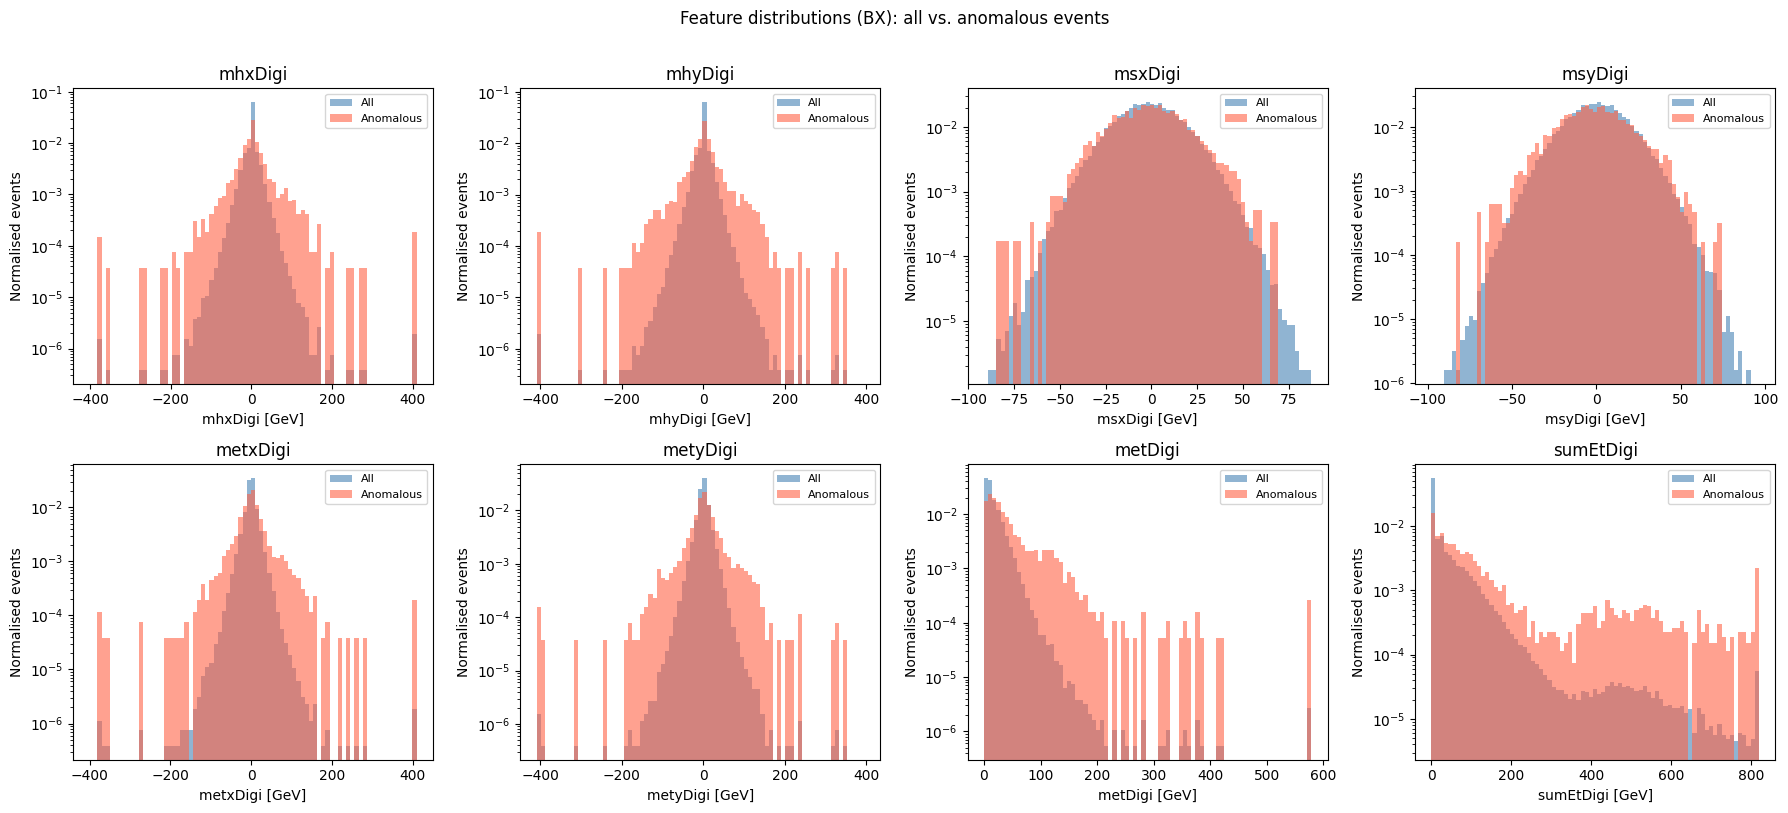

Saved: performance_gFEX_MET_AD/feature_distributions_BX.png


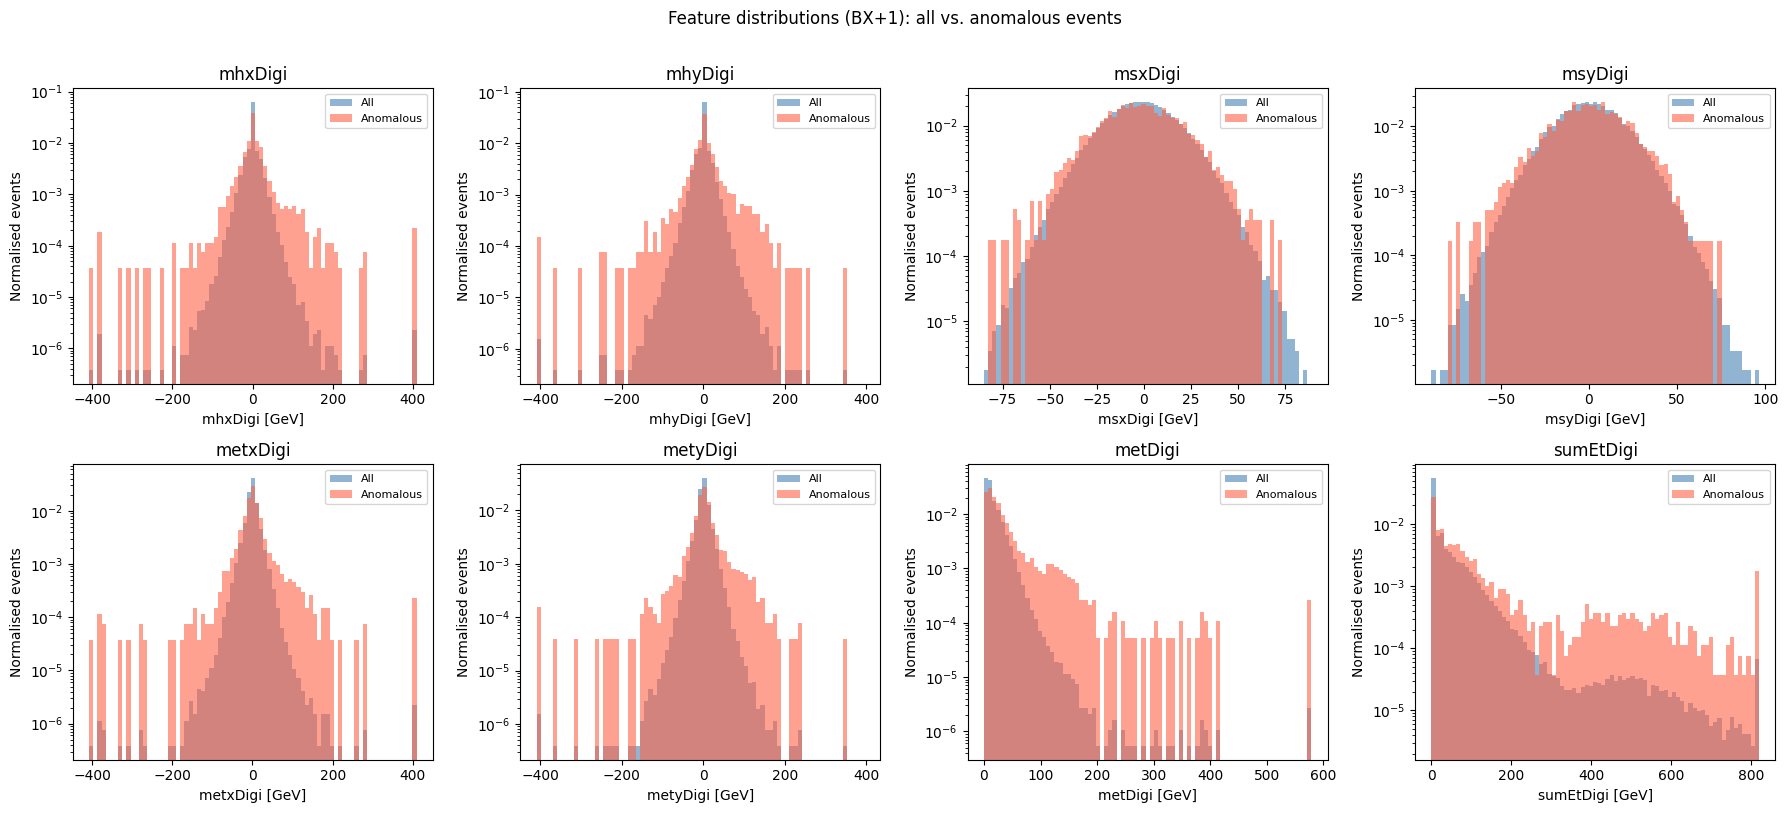

Saved: performance_gFEX_MET_AD/feature_distributions_BXp1.png


In [65]:
for bx_idx, bx_label in enumerate(BX_LABELS):
    X_bx_gev = X_orig[:, bx_idx, :] * SCALE   # inverse-transformed → digitized → GeV

    fig, axes = plt.subplots(2, 4, figsize=(18, 8))
    axes = axes.flatten()

    for i, (feat, ax) in enumerate(zip(BASE_FEATURES, axes)):
        vals_all  = X_bx_gev[:, i]
        vals_anom = X_bx_gev[is_anomaly, i]

        bins = np.linspace(np.percentile(vals_all, 0.0001), np.percentile(vals_all, 99.9999), 80)

        ax.hist(vals_all,  bins=bins, alpha=0.6, density=True, log=True, label="All",       color="steelblue")
        ax.hist(vals_anom, bins=bins, alpha=0.6, density=True, log=True, label="Anomalous", color="tomato")
        ax.set_xlabel(f"{feat} [GeV]")
        ax.set_ylabel("Normalised events")
        ax.set_title(feat)
        ax.legend(fontsize=8)

    plt.suptitle(f"Feature distributions ({bx_label}): all vs. anomalous events", y=1.01)
    plt.tight_layout()
    fname = OUT_DIR / f"feature_distributions_{bx_label.replace('-', 'm').replace('+', 'p').replace(' ', '_')}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}")

## 5. Per-Feature Reconstruction Error

Mean squared error broken down by feature and BX position for anomalous events, shown as a heatmap (BX × feature). Highlights which features and which bunch crossings drive the anomaly score.

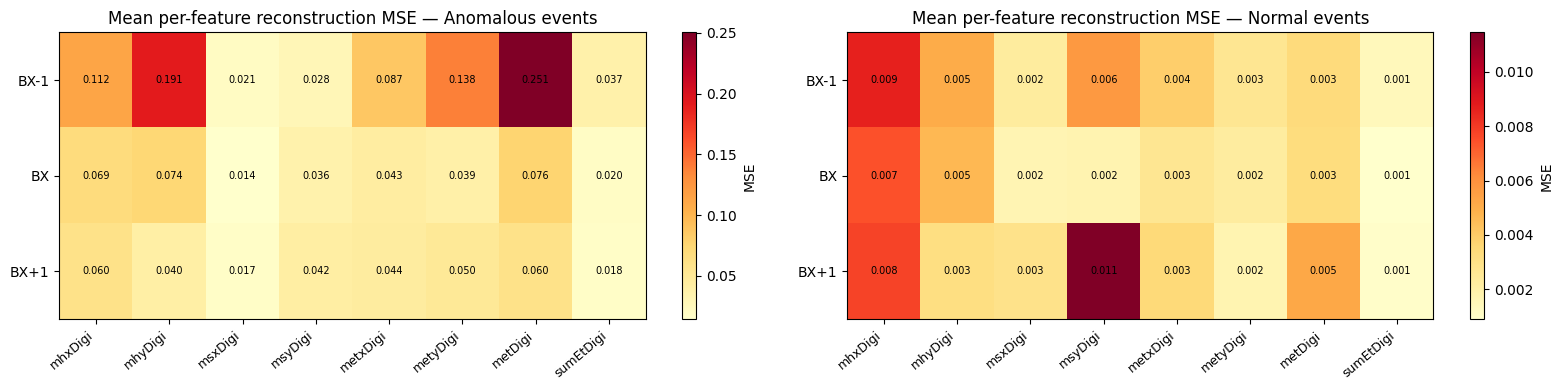

In [66]:
sq_err = (X - X_recon) ** 2   # (N, 3, 8)

mean_err_anom = sq_err[is_anomaly].mean(axis=0)   # (3, 8)
mean_err_norm = sq_err[~is_anomaly].mean(axis=0)  # (3, 8)

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

for ax, data, title in zip(
    axes,
    [mean_err_anom, mean_err_norm],
    ["Anomalous events", "Normal events"],
):
    im = ax.imshow(data, aspect="auto", cmap="YlOrRd")
    ax.set_xticks(range(N_FEAT))
    ax.set_xticklabels(BASE_FEATURES, rotation=40, ha="right", fontsize=9)
    ax.set_yticks(range(N_BX))
    ax.set_yticklabels(BX_LABELS)
    ax.set_title(f"Mean per-feature reconstruction MSE — {title}")
    plt.colorbar(im, ax=ax, label="MSE")

    for bx in range(N_BX):
        for f in range(N_FEAT):
            ax.text(f, bx, f"{data[bx, f]:.3f}", ha="center", va="center", fontsize=7)

plt.tight_layout()
plt.savefig(OUT_DIR / "per_feature_reconstruction_error.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Cross-BX MET Correlation Analysis

Two complementary views of cross-BX structure:

- **MET magnitude correlation** — scatter plots of `metDigi` across BX pairs, plus Pearson ρ, for normal vs. anomalous events. Anomalies may show unusual jumps or anti-correlations in MET magnitude.
- **MET direction** — `φ = atan2(metyDigi, metxDigi)` per BX; the angular difference Δφ between consecutive BXs measures how much the MET vector rotates. Large Δφ in anomalous events suggests something other than pileup noise.

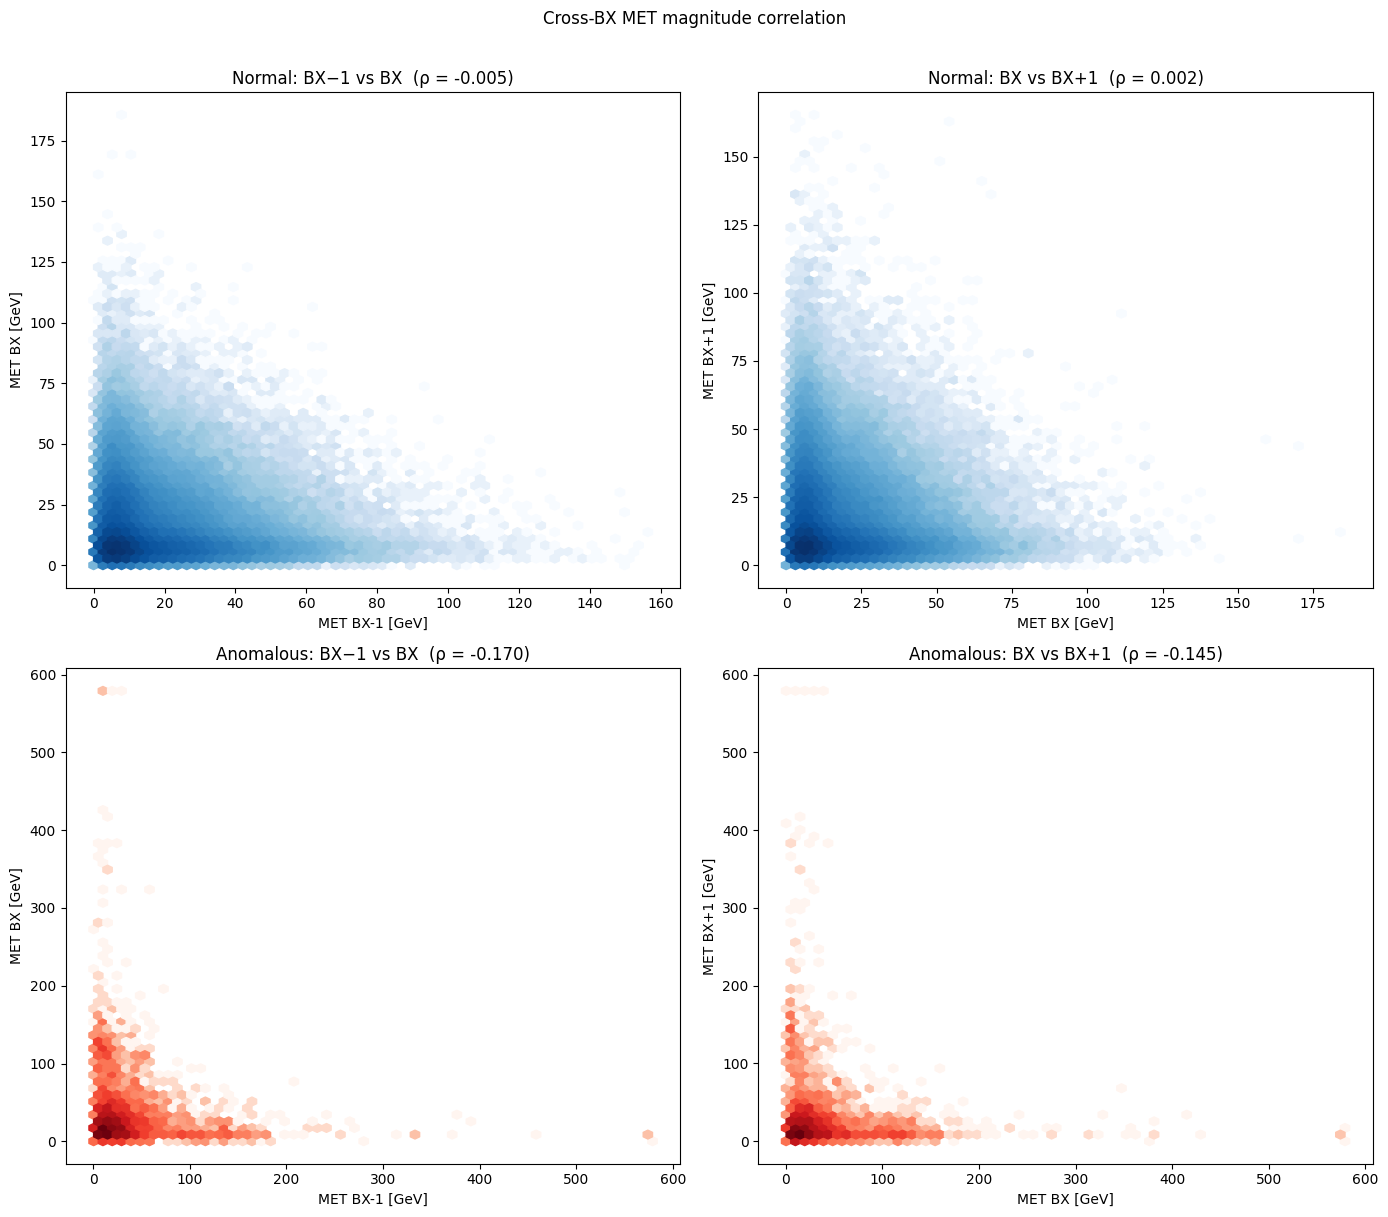

In [67]:
# feature indices (from BASE_FEATURES order)
IDX_METX = BASE_FEATURES.index("metxDigi")
IDX_METY = BASE_FEATURES.index("metyDigi")
IDX_MET  = BASE_FEATURES.index("metDigi")

# Use X_orig (digitized units) for physical quantities
met = X_orig[:, :, IDX_MET] * SCALE   # GeV, shape (N, 3)
phi = np.arctan2(X_orig[:, :, IDX_METY], X_orig[:, :, IDX_METX])   # radians, shape (N, 3)

# -----------------------------------------------------------------------
# 6a. MET magnitude scatter plots: BX-1 vs BX, and BX vs BX+1
# -----------------------------------------------------------------------
pairs = [
    (0, 1, "BX−1 vs BX"),
    (1, 2, "BX vs BX+1"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for col, (bx_a, bx_b, pair_label) in enumerate(pairs):
    for row, (mask, label, color) in enumerate([
        (~is_anomaly, "Normal",    "steelblue"),
        ( is_anomaly, "Anomalous", "tomato"),
    ]):
        ax = axes[row, col]
        x_vals = met[mask, bx_a]
        y_vals = met[mask, bx_b]
        rho = np.corrcoef(x_vals, y_vals)[0, 1]

        ax.hexbin(x_vals, y_vals, gridsize=60, cmap="Blues" if color == "steelblue" else "Reds",
                  mincnt=1, norm=mcolors.LogNorm())
        ax.set_xlabel(f"MET {BX_LABELS[bx_a]} [GeV]")
        ax.set_ylabel(f"MET {BX_LABELS[bx_b]} [GeV]")
        ax.set_title(f"{label}: {pair_label}  (ρ = {rho:.3f})")

plt.suptitle("Cross-BX MET magnitude correlation", y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / "crossBX_met_magnitude_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

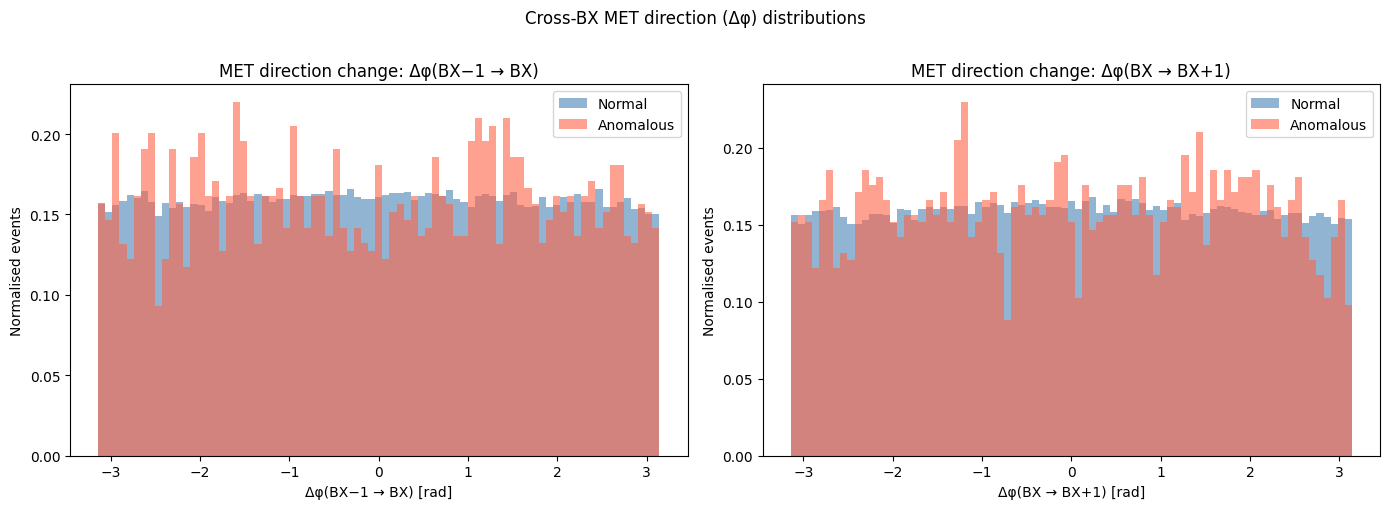

BX-1→BX  |  normal   median |Δφ| = 1.549 rad  |  anomalous median |Δφ| = 1.560 rad
BX→BX+1  |  normal   median |Δφ| = 1.545 rad  |  anomalous median |Δφ| = 1.543 rad


In [68]:
# -----------------------------------------------------------------------
# 6b. MET direction: angular difference Δφ between consecutive BXs
# -----------------------------------------------------------------------

def delta_phi(phi_a, phi_b):
    """Wrap angular difference into [-π, π]."""
    dphi = phi_b - phi_a
    return (dphi + np.pi) % (2 * np.pi) - np.pi

dphi_prev = delta_phi(phi[:, 0], phi[:, 1])   # BX−1 → BX
dphi_next = delta_phi(phi[:, 1], phi[:, 2])   # BX   → BX+1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, dphi, label in zip(axes, [dphi_prev, dphi_next], ["Δφ(BX−1 → BX)", "Δφ(BX → BX+1)"]):
    bins = np.linspace(-np.pi, np.pi, 80)
    ax.hist(dphi[~is_anomaly], bins=bins, alpha=0.6, density=True, label="Normal",    color="steelblue")
    ax.hist(dphi[ is_anomaly], bins=bins, alpha=0.6, density=True, label="Anomalous", color="tomato")
    ax.set_xlabel(f"{label} [rad]")
    ax.set_ylabel("Normalised events")
    ax.set_title(f"MET direction change: {label}")
    ax.legend()

plt.suptitle("Cross-BX MET direction (Δφ) distributions", y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / "crossBX_met_direction.png", dpi=150, bbox_inches="tight")
plt.show()

for dphi, label in [(dphi_prev, "BX-1→BX"), (dphi_next, "BX→BX+1")]:
    print(f"{label}  |  normal   median |Δφ| = {np.median(np.abs(dphi[~is_anomaly])):.3f} rad"
          f"  |  anomalous median |Δφ| = {np.median(np.abs(dphi[is_anomaly])):.3f} rad")